In [60]:
from tracepro.app import TP_app
from tracepro.element import Element
from tracepro.source import Source

import json
import numpy as np
import matplotlib.pyplot as plt

### Lens data

In [61]:
with open(r"C:\Users\prisc\Desktop\FAGOR\Proyecto Lente\lente_data.txt", 'r', encoding='utf-8') as data:
    lens_data = json.load(data)

### New file

In [62]:
tracepro_exe = r"C:\Program Files\Lambda Research Corporation\TracePro\TracePro.exe"
working_path =r"C:\Software\tracepro\resultados\ejemplo_lente_1"
tp_file_name = "ejemplo_1"

tp = TP_app(macro_path=working_path)
res = tp.new_file(file_name=tp_file_name, tp_path=working_path)

### Lens

In [63]:
# Lente:

r1 = lens_data['r1'] / 1000
r2 = lens_data['r2'] / 1000
thickness = lens_data['thickness'] / 1000
heigth = (lens_data['heigth'] / 1000) * 2 

material = ("SCHOTT", "BK7")
# material = ("", "")
surf1 = ("sphere", r1)
surf2 = ("sphere", r2)
aperture = ("circle", heigth)
# obstruction = ("rectangle", "1 2 3 4 5")
obstruction = ("none", "")
surf_1_pos = (0, 0, 0)
surf_2_pos = (0, 0, 0)
surf_1_tilt = surf_2_pos
surf_2_tilt = surf_2_pos

lente = Element(name="Lente_1") 
tp.add_function(lente.lens(thickness=thickness, r1=surf1, r2=surf2, aperture=aperture, obstruction=obstruction, material=material, 
                           surf_1_pos=surf_1_pos, surf_1_tilt=surf_1_tilt, surf_2_pos=surf_2_pos, surf_2_tilt=surf_2_tilt, degrees=False))

# Name surfaces:
tp.name_surfaces(name="r1", object_name=lente.name, surface_num=0)
tp.name_surfaces(name="r2", object_name=lente.name, surface_num=1)
tp.apply_material(material=("SCHOTT", "F7"), object_name=lente.name)

### Block

In [64]:
# Block primitive solid:

depth = lens_data['receptor_depth'] / 1000
width = lens_data['receptor_width'] / 1000
length = lens_data['receptor_length'] / 1000
sp = lens_data['sp'] / 1000

dimensions = (depth, width, length) # x, y, z
center_pos = (0, 0, sp)
rotation = (0, 0, 0)
orientation_method = ("angles", rotation, "")
degrees = False

detector = Element(name="Detector")
tp.add_function(detector.block(dimensions=dimensions, center=center_pos, orientation_method=orientation_method, degrees=degrees))

tp.name_surfaces(name="Plano de deteccion", object_name=detector.name, surface_num=0)
tp.apply_property(property=("default", "perfect absorber"), object_name=detector.name, surface_num=0)

### Source

In [65]:
# Source
s = lens_data['s'] / 1000
radius = lens_data['emisor_radius'] / 1000

position = (0, 0, s)
flux = 10000

fuente = Source(name="Fuente", source_num=0)
tp.add_function(fuente.add_grid_source())
tp.add_function(fuente.grid_settings(position=position, boundary_type="annular", boundary1=radius, boundary2=0, pattern_type="random", pattern1=flux, pattern2="", flux=flux,
                                     units="radiometric", emission_type=0,))
tp.add_function(fuente.set_wavelength(wavelength=(0.555, 1)))
# tp.add_function(fuente.grid_beam_setup(spatial_profile=("gaussian", 0.5, 0.2), angular_profile=("uniform", 15, ""), units="degrees"))

### Analysis

In [66]:
tp.add_function(fuente.raytrace())
tp.select_detection_surface(object_name=detector.name, surface_num=0)
tp.add_function(fuente.irradiance_analysis(ray_type="absorbed", smooth=True))
tp.save_irradiance_map(save_path=working_path, file_name='prueba_ejemplo_1', extension="png")
tp.save_file(file_name=tp_file_name, tp_path=working_path)

In [67]:
tp.execute()

Successfully completed


''

### Move and analysis:

In [ ]:
start = sp - 2
stop = sp + 25
distances = np.linspace(start, stop, 10)
num_distances = len(distances)


for i, dist in enumerate(distances):

    tp.move_object(object_name=detector.name, mode="absolute", distance=(0, 0, dist))
    tp.select_detection_surface(object_name=detector.name, surface_num=0)
    tp.add_function(fuente.raytrace())
    tp.add_function(fuente.irradiance_analysis(ray_type="incident", smooth=True))
    tp.save_irradiance_map(save_path=working_path, file_name=f"irradiance_map_{i+1}", extension="txt")

tp.save_file(file_name=tp_file_name, tp_path=working_path)
tp.execute(graphic_window=False) 

Successfully completed


''

In [69]:
# tp.delete_macro()

### Data analysis:

In [ ]:
mapas = np.zeros([128, 128, num_distances])

file_names = []
for num in range(1, num_distances + 1):
    name = f"irradiance_map_{num}"
    file_names.append(name)

mapas = tp.txt_map2array(txt_path=working_path, num_files=num_distances, file_name=file_names)

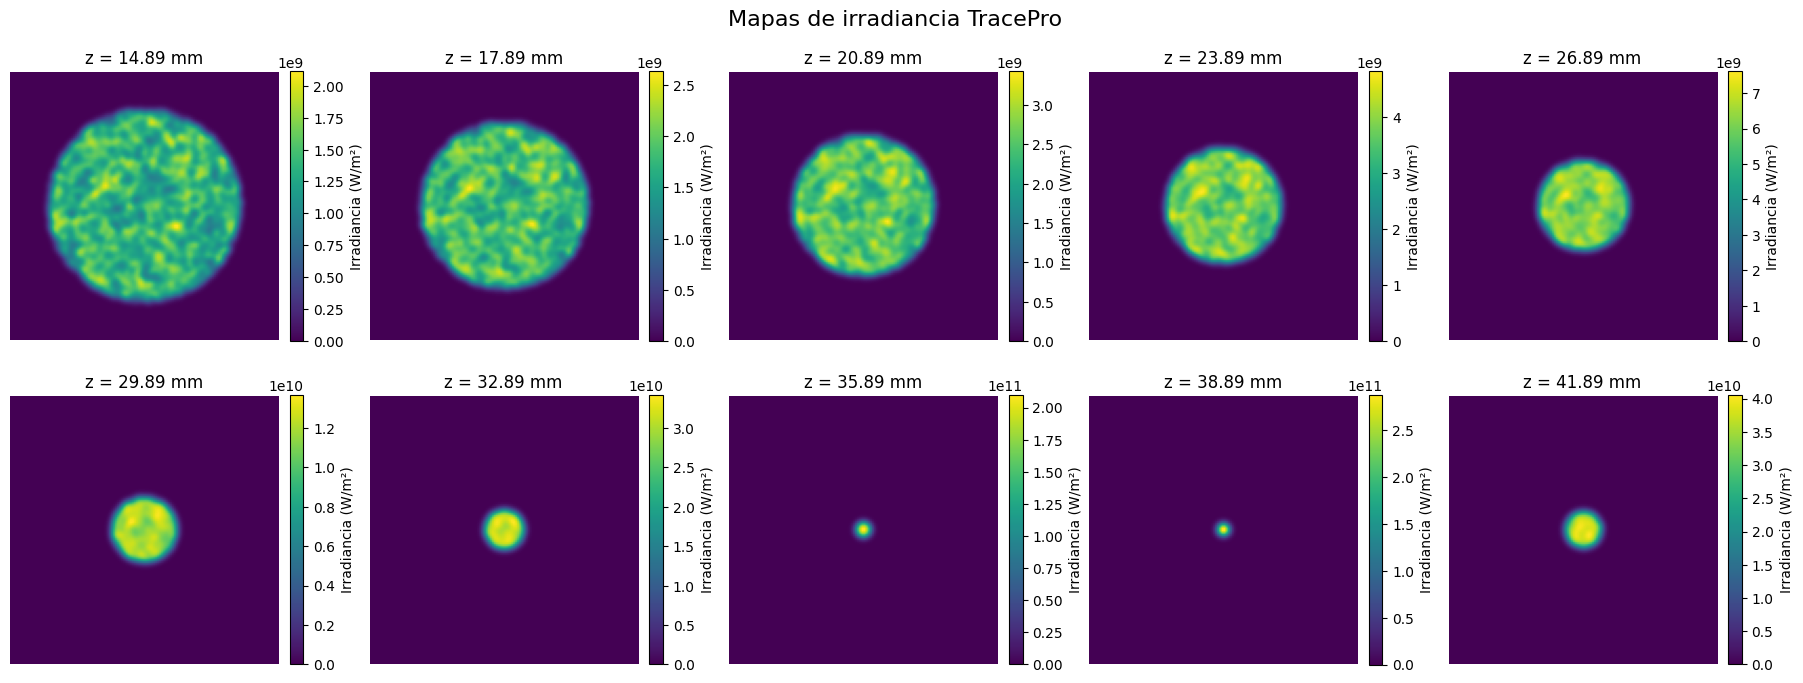

In [71]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i in range(10):
    ax = axes[i // 5, i % 5]   # fila y columna del subplot
    im = ax.imshow(mapas[:, :, i], origin="lower")
    ax.set_title(f"z = {(distances[i]):.2f} mm")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia (W/m²)")

plt.suptitle("Mapas de irradiancia TracePro", fontsize=16)
plt.tight_layout()
plt.show()